In [ ]:
!pip install pyDOE

In [ ]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from pyDOE import lhs

In [ ]:
# Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"] #lb.to(device)
        self.UpperBounds = model_parameters["UpperBounds"] #ub.to(device)
        self.UnknownParameters = model_parameters["UnknownParameters"] #lambda1, lambda2
        self.InputDimensions = model_parameters["InputDimensions"] #2
        self.OutputDimensions = model_parameters["OutputDimensions"] #1
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"] #10
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"] #4
        self.ActivationFunction = model_parameters["ActivationFunction"] #nn.Tanh()
        self.RetrainSeed = model_parameters["RetrainSeed"] #0
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def internalEnergyBalanceResidue(self, X, u):

        lambda1, lambda2 = self.UnknownParameters

        grad_u = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        grad_u_x, grad_u_t = grad_u[:, 0:1], grad_u[:, 1:2]

        grad2_u = torch.autograd.grad(grad_u_x, X, grad_outputs=torch.ones_like(grad_u_x), create_graph=True)[0]
        grad2_u_x = grad2_u[:, 0:1]

        residue = grad_u_t - lambda1*grad2_u_x + lambda2*u*(u**2 - 1)

        return residue

    def init_xavier(self):
        torch.manual_seed(self.RetrainSeed)

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        features = self.X[idx, :]
        target = self.y[idx, :]
        return features, target


In [ ]:
torch.manual_seed(0)
#np.random.seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Number of collocation points
N_dom = 10000 # Number of collocation points for evaluating the residuals

# Train, validation and testing sets
tags = ["Domain", "BC", "IC", "LabelledData"]

# Initialize list of dataset objects
ds = []

# Load the data
x_data = torch.from_numpy(np.load("AC_data_input.npy")).type(torch.float32)
y_data = torch.from_numpy(np.load("AC_data_output.npy")).type(torch.float32)

x_tensor = x_data[0, :, 0]
xi, xf = x_tensor[0], x_tensor[-1]
ti, tf = 0, 1
t_tensor = torch.linspace(ti, tf, len(x_tensor))

## Collocation points for evaluating the residual of the governing PDE
# Generate collocation points within the domain using Latin Hypercube Sampling (LHS) strategy
lb = torch.tensor([xi, ti])
ub = torch.tensor([xf, tf])
X_dom = (lb + (ub - lb)*lhs(2, N_dom)).to(torch.float32)
y_dom = torch.zeros((N_dom, 1))

ds.append(CustomDataset(X_dom, y_dom))

idx_data = np.random.randint(0, 1000, 1).item()
print('idx_data: ', idx_data)

# BC
u_bc = torch.zeros((2*(len(x_data)-1), 1))
X_data_bc_l = torch.cat([torch.full((len(t_tensor)-2, 1), xi), t_tensor[1:-1].view(-1, 1)], axis=1)
X_data_bc_r = torch.cat([torch.full((len(t_tensor)-2, 1), xf), t_tensor[1:-1].view(-1, 1)], axis=1)
X_bc = torch.cat([X_data_bc_l, X_data_bc_r], axis=0)
ds.append(CustomDataset(X_bc, u_bc))

# IC
u_ic = x_data[idx_data, :, 1].view(-1, 1)
X_ic = torch.cat([x_tensor.view(-1, 1), torch.zeros((len(x_tensor), 1))], axis=1)
ds.append(CustomDataset(X_ic, u_ic))

# Labelled data
u1_data = y_data[idx_data].view(-1, 1)
X_data_u1 = torch.cat([x_tensor.view(-1, 1), torch.ones((len(x_tensor), 1))], axis=1)
ds.append(CustomDataset(X_data_u1, u1_data))

# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

idx_data:  378


<ipython-input-71-117749c37c7c>:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_dom = (lb + (ub - lb)*lhs(2, N_dom)).to(torch.float32)


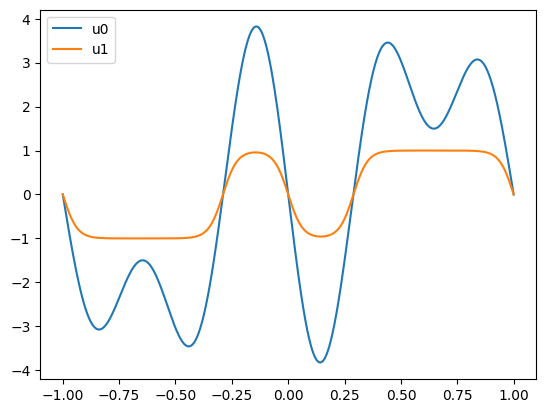

In [ ]:
plt.plot(x_tensor.numpy(), u_ic.numpy(), label='u0')
plt.plot(x_tensor.numpy(), u1_data.numpy(), label='u1')
plt.legend()
plt.show()

In [ ]:
# Input dictionary for model instance
inv_params = nn.Parameter(torch.tensor([1.0, 1.0]), requires_grad=True) #Make alpha a trainable parameter
tanh = nn.Tanh()
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "UnknownParameters": inv_params,
    "InputDimensions": 2,
    "OutputDimensions": 1,
    "NumberOfNeurons": 40,
    "NumberOfHiddenLayers": 4,
    "ActivationFunction": nn.Tanh(),
    "RetrainSeed": 0
}
print('lambda1: ', inv_params[0].item(), 'lambda2: ', inv_params[1].item())

lambda1:  1.0 lambda2:  1.0


In [ ]:
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage
epochs = 20000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
lambda1_values = []
lambda2_values = []
train_keys = ['Overall', 'Domain', 'BC', 'IC', 'Data', 'lambda1', 'lambda2']
for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    for tag in tags:
        X = (datasets[tag].X).to(device)
        y = (datasets[tag].y).to(device)
        if tag=='Domain':
            X.requires_grad = True
            T = model(X)
            y_hat = model.internalEnergyBalanceResidue(X, T)
            loss = loss_fn(y_hat, y)
            loss_list.append(loss)

        else:
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    if loss<1e-4:
        print('Overall loss dropped below tolerance value of 1e-4. Training stopped.')
        break
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    loss_train_data.append(loss_list[4].item())

    lambda1 = model.UnknownParameters[0].item()
    lambda2 = model.UnknownParameters[1].item()
    lambda1_values.append(lambda1)
    lambda2_values.append(lambda2)
    loss_list.append(lambda1)
    loss_list.append(lambda2)

    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)


##TRAIN## Adam - Epoch: 0, Overall: 9.86553e+00, Domain: 3.17236e+00, BC: 1.82632e-01, IC: 5.87782e+00, Data: 6.32713e-01, lambda1: 9.90000e-01, lambda2: 1.01000e+00, 
##TRAIN## Adam - Epoch: 100, Overall: 5.20647e+00, Domain: 1.36627e-01, BC: 4.78955e-01, IC: 4.18782e+00, Data: 4.03064e-01, lambda1: 8.44950e-01, lambda2: 9.19540e-01, 
##TRAIN## Adam - Epoch: 200, Overall: 4.88604e+00, Domain: 1.17249e-01, BC: 3.62249e-01, IC: 3.95803e+00, Data: 4.48511e-01, lambda1: 8.44714e-01, lambda2: 9.19082e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 4.66758e+00, Domain: 9.61842e-02, BC: 2.73825e-01, IC: 3.83569e+00, Data: 4.61886e-01, lambda1: 8.46444e-01, lambda2: 9.14301e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 4.49686e+00, Domain: 6.91297e-02, BC: 2.21882e-01, IC: 3.76729e+00, Data: 4.38561e-01, lambda1: 8.58052e-01, lambda2: 9.05672e-01, 
##TRAIN## Adam - Epoch: 500, Overall: 4.38651e+00, Domain: 5.85193e-02, BC: 1.99337e-01, IC: 3.70976e+00, Data: 4.18896e-01, lambda1: 8.67542e-01, lambd

In [ ]:
u0_pred = model(X_ic.to(device))
u1_pred = model(X_data_u1.to(device))

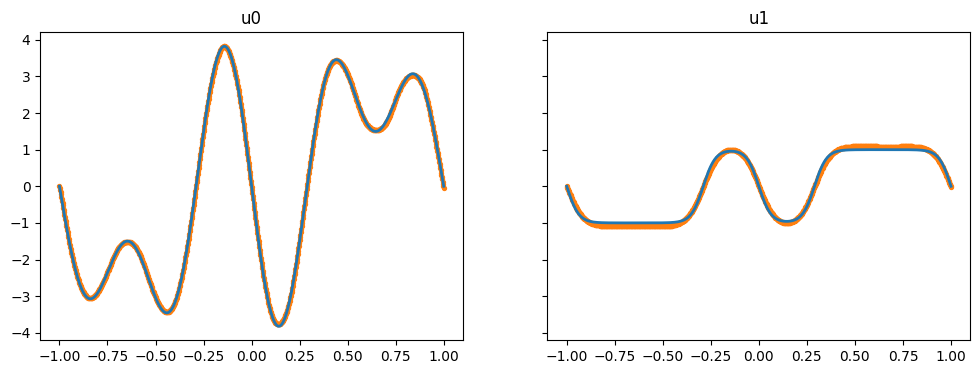

In [ ]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), sharey=True)
ax1.plot(x_tensor.numpy(), u_ic.numpy(), label="True Solution", c="C0", lw=2)
ax1.scatter(x_tensor.numpy(), u0_pred.detach().cpu().numpy(), label="Approximate Solution", s=8, c="C1")
ax1.set_title('u0')
ax2.plot(x_tensor.numpy(), u1_data.numpy(), label="True Solution", c="C0", lw=2)
ax2.scatter(x_tensor.numpy(), u1_pred.detach().cpu().numpy(), label="Approximate Solution", s=8, c="C1")
ax2.set_title('u1')
plt.show()

Text(0.5, 1.0, 'lambda2')

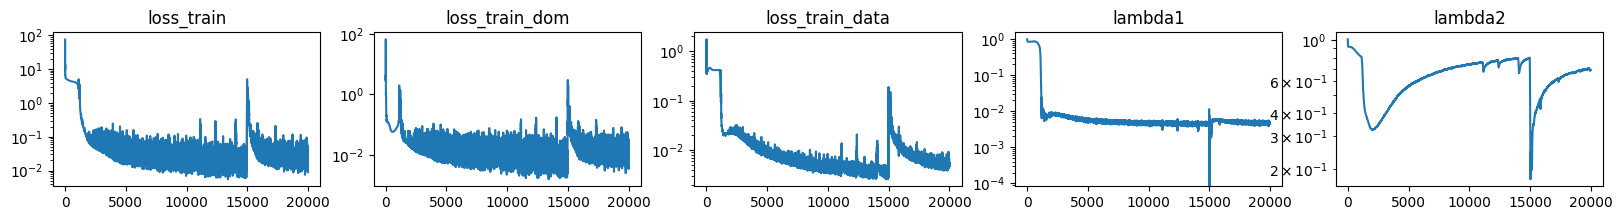

In [ ]:
fig2, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20,2))
ax1.semilogy(loss_train); ax1.set_title('loss_train')
ax2.semilogy(loss_train_dom); ax2.set_title('loss_train_dom')
ax3.semilogy(loss_train_data); ax3.set_title('loss_train_data')
ax4.semilogy(lambda1_values); ax4.set_title('lambda1')
ax5.semilogy(lambda2_values); ax5.set_title('lambda2')

In [ ]:
np.mean(lambda1_values[-1000:])

np.float64(0.004771748489933088)

In [ ]:
np.mean(lambda2_values)

np.float64(0.6360646969474852)

In [ ]:
# Solution of the Allen-Cahn equation via FEM
ttot = tf - ti
t_fem = torch.linspace(ti, tf, 50)
nt = len(t_fem)
nnod = len(x_tensor)
nele = nnod - 1

lambda1 = 0.0025
lambda2 = 6e-1

K = np.zeros((nnod, nnod))
M1 = np.zeros((nnod, nnod))
M2 = np.zeros((nnod, nnod))
for i in range(nele):
    hk = np.abs(x_tensor[i+1] - x_tensor[i])
    ke = np.array([[1/hk, -1/hk], [-1/hk, 1/hk]])
    K[i:i+2, i:i+2] = K[i:i+2, i:i+2] + ke
    me = np.array([[hk/3, hk/6], [hk/6, hk/3]])
    M1[i:i+2, i:i+2] = M1[i:i+2, i:i+2] + me
    me = np.array([[hk/5, hk/20], [hk/20, hk/5]])
    M2[i:i+2, i:i+2] = M2[i:i+2, i:i+2] + me

U = np.zeros((nnod, nt))
U[:, 0:1] = u_ic
for i in range(nt-1):
    ui = U[:, i:i+1]
    dt = t_fem[i+1] - t_fem[i]
    A = M1/dt + lambda1*K
    A[0, :] = 0; A[0, 0] = 1
    A[-1, :] = 0; A[-1, -1] = 1
    b = 1/dt*np.dot(M1, ui) + lambda2*np.dot(M1, ui) - lambda2*np.dot(M2, ui**3)
    b[0] = 0; b[-1] = 0
    u = np.linalg.solve(A, b)
    U[:, i+1:i+2] = u


<ipython-input-63-a1703babcdaf>:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  hk = np.abs(x_tensor[i+1] - x_tensor[i])
<ipython-input-63-a1703babcdaf>:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  U[:, 0:1] = u_ic
<ipython-input-63-a1703babcdaf>:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  A = M1/dt + lambda1*K
<ipython-input-63-a1703babcdaf>:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  b = 1/dt*np.dot(M1, ui) + lambda2*np.dot(M1, ui) - lambda2*np.dot(M2, ui**3)
<ipython-input-63-a1703babcdaf>:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so

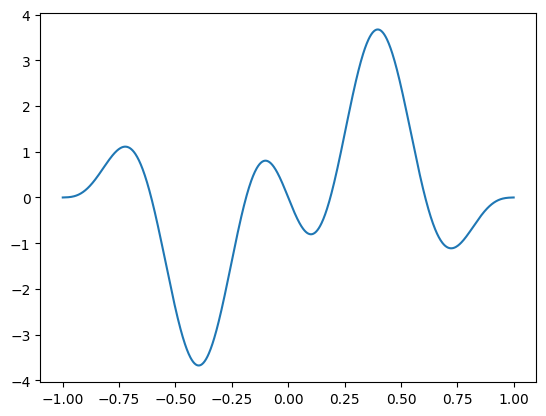

In [ ]:
plt.plot(x_tensor.numpy(), U[:, 0:1])
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import clear_output, HTML

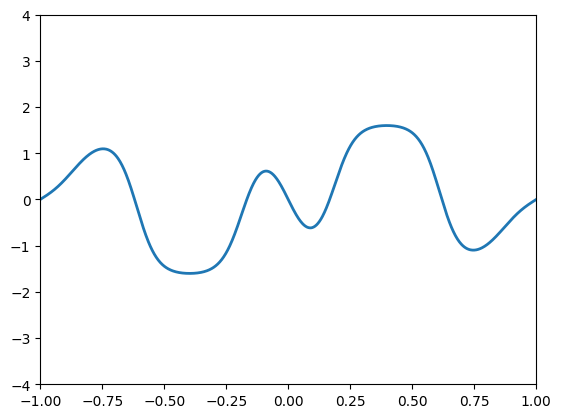

In [ ]:
# Plotting
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_xlim(-1, 1)
ax.set_ylim(-4, 4)

def init():
    line.set_data(x_tensor.numpy(), U[:, 0])
    return line,

def update(frame):
    line.set_data(x_tensor.numpy(), U[:, frame])
    return line,

ani = FuncAnimation(fig, update, frames=nt, init_func=init, blit=True)

HTML(ani.to_jshtml())